## ESM-FCN vs ESM-FCN_BE

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_log_file(metrics_csv_be, metrics_csv_b, metrics_csv_e, coords, metrics_img):
    df_be = pd.read_csv(metrics_csv_be)
    df_b = pd.read_csv(metrics_csv_b)
    df_e = pd.read_csv(metrics_csv_e)

    sns.set_theme(style="darkgrid")
    fig, ((ax_tr_be, ax_tr), (ax_te_be, ax_te)) = plt.subplots(2, 2, figsize=(16, 9))  # 1 rows, 2 columns
    fontsize = 16

    # Plot 1: Training BE Metrics
    ax_tr_be.plot(df_be['Epoch'], df_be[f'Train Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_tr_be.plot(df_be['Epoch'], df_be[f'Train Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_tr_be.tick_params(axis='x', bottom=False, labelbottom=False)    
    ax_tr_be.set_xlim(-50, 1050)
    ax_tr_be.set_ylabel('RMSE', fontsize=fontsize)
    ax_tr_be.tick_params(axis='y', labelsize=fontsize)
    ax_tr_be.set_ylim(-0.1, 1.3)
    ax_tr_be.legend(title='Training (Combined)', loc='upper right', frameon=False)

    # Plot 2: Testing BE Metrics
    ax_te_be.plot(df_be['Epoch'], df_be[f'Test Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_te_be.plot(df_be['Epoch'], df_be[f'Test Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_te_be.set_xlabel('Epochs', fontsize=fontsize)
    ax_te_be.tick_params(axis='x', labelsize=fontsize)
    ax_te_be.set_xlim(-50, 1050)
    ax_te_be.set_ylabel('RMSE', fontsize=fontsize)
    ax_te_be.tick_params(axis='y', labelsize=fontsize)
    ax_te_be.set_ylim(-0.1, 1.3)
    ax_te_be.legend(title='Testing (Combined)', loc='upper right', frameon=False)

    # Plot 3: Training Metrics
    ax_tr.plot(df_b['Epoch'], df_b[f'Train RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_tr.plot(df_e['Epoch'], df_e[f'Train RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_tr.tick_params(axis='x', bottom=False, labelbottom=False)   
    ax_tr.set_xlim(-50, 1050)
    ax_tr.tick_params(axis='y', left=False, labelleft=False)
    ax_tr.set_ylim(-0.1, 1.3)
    ax_tr.legend(title='Training (Separate)', loc='upper right', frameon=False)

    # Plot 4: Testing Metrics
    ax_te.plot(df_b['Epoch'], df_b[f'Test RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax_te.plot(df_e['Epoch'], df_e[f'Test RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax_te.set_xlabel('Epochs', fontsize=fontsize)
    ax_te.tick_params(axis='x', labelsize=fontsize)
    ax_te.set_xlim(-50, 1050)
    ax_te.tick_params(axis='y', left=False, labelleft=False)
    ax_te.set_ylim(-0.1, 1.3)
    ax_te.legend(title='Testing (Separate)', loc='upper right', frameon=False)

    # Plot Best Test Loss
    best_df_be_b_rmse = find_best_epoch(metrics_csv_be, f'Test Binding RMSE')
    best_df_be_e_rmse = find_best_epoch(metrics_csv_be, f'Test Expression RMSE')
    best_df_b_rmse = find_best_epoch(metrics_csv_b, f'Test RMSE')
    best_df_e_rmse = find_best_epoch(metrics_csv_e, f'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print(f"\tBE Binding: epoch {best_df_be_b_rmse[0]}, rmse {best_df_be_b_rmse[1]:.4f}")
    print(f"\tBE Expression: epoch {best_df_be_e_rmse[0]}, rmse {best_df_be_e_rmse[1]:.4f}")
    print(f"\tBinding: epoch {best_df_b_rmse[0]}, rmse {best_df_b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df_e_rmse[0]}, rmse {best_df_e_rmse[1]:.4f}")

    ax_te_be.annotate(
        f'({best_df_be_b_rmse[0]}, {best_df_be_b_rmse[1]:.4f})', best_df_be_b_rmse, 
        textcoords="offset points", xytext=(coords['BE Binding']), ha='center', va='top', color='tab:blue', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax_te_be.annotate(
        f'({best_df_be_e_rmse[0]}, {best_df_be_e_rmse[1]:.4f})', best_df_be_e_rmse, 
        textcoords="offset points", xytext=(coords['BE Expression']), ha='center', va='top', color='tab:orange', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax_te.annotate(
        f'({best_df_b_rmse[0]}, {best_df_b_rmse[1]:.4f})', best_df_b_rmse, 
        textcoords="offset points", xytext=(coords['Binding']), ha='center', va='top', color='tab:blue', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax_te.annotate(
        f'({best_df_e_rmse[0]}, {best_df_e_rmse[1]:.4f})', best_df_e_rmse, 
        textcoords="offset points", xytext=(coords['Expression']), ha='center', va='top', color='tab:orange', fontsize=fontsize-6,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

Comparing: best ESM-FCN_BE binding and expression vs best ESM-FCN binding and best ESM-FCN expression.

Best test RMSE at epoch x:
	BE Binding: epoch 72, rmse 0.5005
	BE Expression: epoch 988, rmse 0.3102
	Binding: epoch 965, rmse 0.5185
	Expression: epoch 233, rmse 0.3145


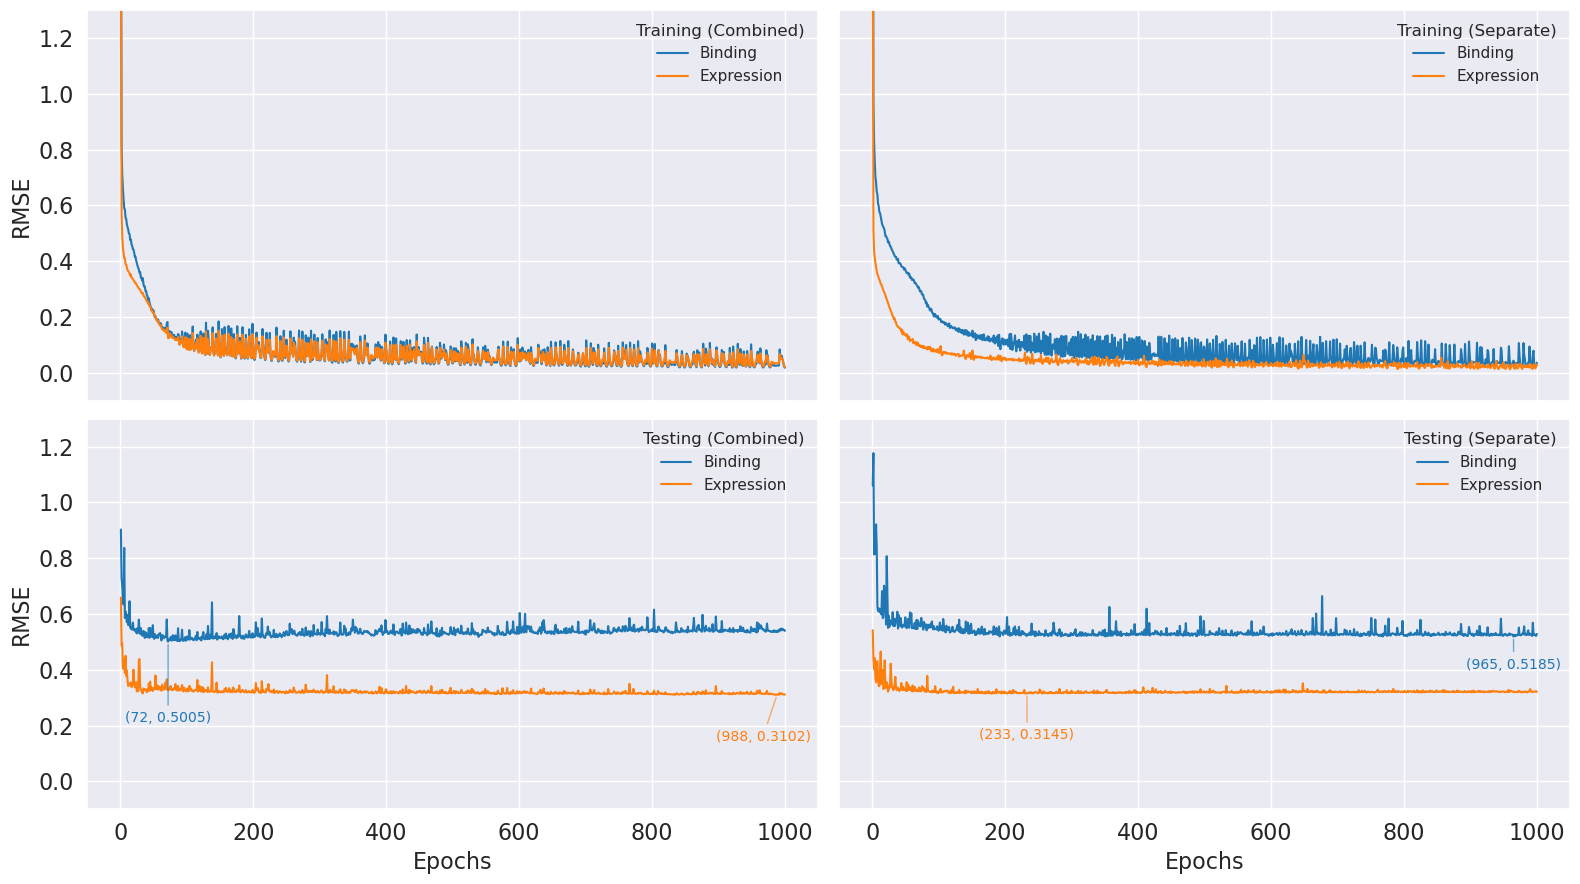

In [2]:
be_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46/esm_fcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"

coords = {
    "BE Binding": (0,-50),
    "BE Expression": (-10,-25),
    "Binding": (0,-15),
    "Expression": (0,-25)
}

comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/best_esm-fcn_BE.vs.best_esm-fcn"
plot_comparative_log_file(be_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, coords, f"{comparison_file}.model_comp.pdf")

--- 
## ESM-FCN_BE
This model has the point with the lowest binding and expression rmse values. The best saved

Pull model predicted values and rmse losses per seq_id out.

In [4]:
import os
import sys
import tqdm
import time
import torch
import random
import datetime
import pandas as pd
import numpy as np
from typing import Union
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, EsmModel

def load_model(saved_model_pth, device):
    saved_state = torch.load(saved_model_pth, map_location=device)

    model_state = saved_state['model_state_dict']
    optimizer_state = saved_state['optimizer_state_dict']

    epoch = saved_state['epoch']
    loss = saved_state['loss']

    print(f"Loaded in model from {saved_model_pth}, saved at epoch {epoch}, rmse loss {loss}")
    return model_state, optimizer_state, epoch, loss

class DMSDataset_BE(Dataset):
    """ Binding and Expression DMS Dataset, multi target. """
    
    def __init__(self, csv_file:str):
        """
        Load from csv file into pandas:
        - sequence label ('labels'), 
        - 'sequence',
        - binding target,
        - expression target
        """
        try:
            self.full_df = pd.read_csv(csv_file, sep=',', header=0)
        except (FileNotFoundError, pd.errors.ParserError, Exception) as e:
            print(f"Error reading in .csv file: {csv_file}\n{e}", file=sys.stderr)
            sys.exit(1)

    def __len__(self) -> int:
        return len(self.full_df)

    def __getitem__(self, idx):
        # label, seq, binding target, expression target
        return self.full_df['label'][idx], self.full_df['sequence'][idx], self.full_df['ACE2-binding_affinity'][idx], self.full_df['RBD_expression'][idx]

/data/miniconda3/envs/spike_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ESM-FCN_BE

In [20]:
class FCN(nn.Module):
    """ Fully Connected Network """

    def __init__(self,
                 fcn_input_size,    # The number of input features
                 fcn_hidden_size,   # The number of features in hidden layer of FCN.
                 fcn_num_layers):   # The number of fcn layers  
        super().__init__()

        # Creating a list of layers for the FCN
        # Subsequent layers after 1st should be equal to hidden_size for input_size
        layers = []
        input_size = fcn_input_size

        for _ in range(fcn_num_layers):
            layers.append(nn.Linear(input_size, fcn_hidden_size))
            layers.append(nn.ReLU())
            input_size = fcn_hidden_size

        # FCN layers
        self.fcn = nn.Sequential(*layers)

        # FCN output layers - two separate heads for binding and expression
        self.binding_head = nn.Linear(fcn_hidden_size, 1)
        self.expression_head = nn.Linear(fcn_hidden_size, 1)

    def forward(self, x):
        fcn_out = self.fcn(x)

        # Task-specific predictions
        binding_pred = self.binding_head(fcn_out).squeeze(1) # [batch_size]
        expression_pred = self.expression_head(fcn_out).squeeze(1) # [batch_size]

        return binding_pred, expression_pred

# ESM-FCN
class ESM_FCN(nn.Module):
    def __init__(self, esm, fcn):
        super().__init__()
        self.esm = esm
        self.fcn = fcn

    def forward(self, tokenized_seqs):
        with torch.set_grad_enabled(self.training):  # Enable gradients, managed by model.eval() or model.train() in epoch_iteration
            esm_last_hidden_state = self.esm(**tokenized_seqs).last_hidden_state # shape: [batch_size, sequence_length, embedding_dim]
            esm_cls_embedding = esm_last_hidden_state[:, 0, :]  # CLS token embedding (sequence-level representations), [batch_size, embedding_dim]
            binding_preds, expression_preds = self.fcn(esm_cls_embedding) # [batch_size]
        return binding_preds, expression_preds

# MODEL RUNNING
def run_model(model, tokenizer, train_data_loader, test_data_loader, device: str, save_as_dir: str, saved_model_pth:str=None):
    """ Run a model through train and test epochs. """

    model = model.to(device)
    loss_fn = nn.MSELoss(reduction='none').to(device)

    # Load saved model
    if saved_model_pth is not None and os.path.exists(saved_model_pth):
        model_state, _, _, _ = load_model(saved_model_pth, device)
        model.load_state_dict(model_state)

    # Running
    prediction_dict = {
        "seq_id": [],
        "binding_predicted_value":[],
        "expression_predicted_value":[],
        "mode": []
    }

    rmse_dict = {
        "seq_id": [],
        "binding_mse": [],
        "binding_rmse": [],
        "expression_mse": [],
        "expression_rmse": [],
        "mode": [],
    }
   
    # TRAIN
    train_data_iter = tqdm.tqdm(enumerate(train_data_loader),
                desc=f'Training data',
                total=len(train_data_loader),
                bar_format='{l_bar}{r_bar}')

    for batch, batch_data in train_data_iter:
        seq_ids, seqs, binding_targets, expression_targets = batch_data
        binding_targets, expression_targets = binding_targets.to(device).float(), expression_targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)
            
        model.train()
        binding_preds, expression_preds = model(tokenized_seqs)
        batch_binding_losses = loss_fn(binding_preds, binding_targets)
        batch_expression_losses = loss_fn(expression_preds, expression_targets)
        batch_binding_loss = sum(batch_binding_losses)
        batch_expression_loss = sum(batch_expression_losses)
        batch_be_loss = batch_binding_loss + batch_expression_loss
        batch_be_loss.backward()

        for id, b_pred, e_pred in zip(seq_ids, binding_preds, expression_preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["binding_predicted_value"].append(b_pred.item())
            prediction_dict["expression_predicted_value"].append(e_pred.item())
            prediction_dict["mode"].append("train")

        for id, b_mse, e_mse in zip(seq_ids, batch_binding_losses, batch_expression_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["binding_mse"].append(b_mse.item())
            rmse_dict["binding_rmse"].append(np.sqrt(b_mse.item()))
            rmse_dict["expression_mse"].append(e_mse.item())
            rmse_dict["expression_rmse"].append(np.sqrt(e_mse.item()))
            rmse_dict["mode"].append("train")
        
    # TEST
    test_data_iter = tqdm.tqdm(enumerate(test_data_loader),
                desc=f'Testing data',
                total=len(test_data_loader),
                bar_format='{l_bar}{r_bar}')
    
    for batch, batch_data in test_data_iter:
        seq_ids, seqs, binding_targets, expression_targets = batch_data
        binding_targets, expression_targets = binding_targets.to(device).float(), expression_targets.to(device).float()
        tokenized_seqs = tokenizer(seqs, return_tensors="pt").to(device)

        model.eval()
        with torch.no_grad():
            binding_preds, expression_preds = model(tokenized_seqs)
            batch_binding_losses = loss_fn(binding_preds, binding_targets)
            batch_expression_losses = loss_fn(expression_preds, expression_targets)

        for id, b_pred, e_pred in zip(seq_ids, binding_preds, expression_preds):
            prediction_dict["seq_id"].append(id)
            prediction_dict["binding_predicted_value"].append(b_pred.item())
            prediction_dict["expression_predicted_value"].append(e_pred.item())
            prediction_dict["mode"].append("test")

        for id, b_mse, e_mse in zip(seq_ids, batch_binding_losses, batch_expression_losses):
            rmse_dict["seq_id"].append(id)
            rmse_dict["binding_mse"].append(b_mse.item())
            rmse_dict["binding_rmse"].append(np.sqrt(b_mse.item()))
            rmse_dict["expression_mse"].append(e_mse.item())
            rmse_dict["expression_rmse"].append(np.sqrt(e_mse.item()))
            rmse_dict["mode"].append("test")

    prediction_df = pd.DataFrame.from_dict(prediction_dict)
    prediction_df.to_csv(os.path.join(save_as_dir, f"all_predicted_values_best_saved.csv"), index=False)
    print(f"Predictions:\n {prediction_df}")

    rmse_df = pd.DataFrame.from_dict(rmse_dict)
    rmse_df.to_csv(os.path.join(save_as_dir, f"all_rmse_best_saved.csv"), index=False)
    print(f"RMSEs:\n {rmse_df}")

# Run setup
batch_size = 64
num_workers = 4
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Data/results directories
data_dir = '../../data/dms' 
results_dir = '../../results/run_results/esm_fcn'
run_dir = os.path.join(results_dir, f'adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46')
saved_model_pth = os.path.join(run_dir, "best_saved_model.pth")

# Create Dataset and DataLoader
torch.manual_seed(0)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_dataset = DMSDataset_BE(os.path.join(data_dir, "mutation_combined_DMS_OLD_train.csv"))
train_data_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

test_dataset = DMSDataset_BE(os.path.join(data_dir, "mutation_combined_DMS_OLD_test.csv"))
test_data_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=False, 
    num_workers=num_workers, 
    worker_init_fn=seed_worker, 
    generator=torch.Generator().manual_seed(0), 
    pin_memory=True
)

# ESM input
esm_version = "facebook/esm2_t6_8M_UR50D" 
esm = EsmModel.from_pretrained(esm_version, cache_dir='../../../../model_downloads').to(device)
tokenizer = AutoTokenizer.from_pretrained(esm_version, cache_dir='../../../../model_downloads')

# FCN input
size = 320
fcn_input_size = size  
fcn_hidden_size = size
fcn_num_layers = 5
fcn = FCN(fcn_input_size, fcn_hidden_size, fcn_num_layers)

model = ESM_FCN(esm, fcn)

# Run
run_model(model, tokenizer, train_data_loader, test_data_loader, device, run_dir, saved_model_pth)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded in model from ../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46/best_saved_model.pth, saved at epoch 95, rmse loss 0.5978541348200122


Testing data: 100%|| 322/322 [00:16<00:00, 19.16it/s]


Predictions:
                                       seq_id  binding_predicted_value  \
0                SARS-CoV-2-S19E_E141G_N157A                 6.025325   
1                SARS-CoV-2-T63F_Y178V_S184L                 9.118689   
2                     SARS-CoV-2-W106A_G146C                 6.065585   
3           SARS-CoV-2-A18C_R25V_L122T_P149R                 6.147402   
4                       SARS-CoV-2-D59W_P96S                10.168621   
...                                      ...                      ...   
102718      SARS-CoV-2-V11A_V32G_W106G_G146H                 6.054747   
102719  SARS-CoV-2-T3G_K48P_G83E_S147V_V173S                 6.322847   
102720                       SARS-CoV-2-K94H                10.710976   
102721           SARS-CoV-2-T46L_S139T_F185Q                 9.576644   
102722      SARS-CoV-2-A14P_N58V_T140V_C150F                 6.025498   

        expression_predicted_value   mode  
0                         8.142976  train  
1                    

Get WT locations.

In [9]:
import os
import pandas as pd

data_dir = "../../data/dms/original"
binding_df = pd.read_csv(os.path.join(data_dir, "binding_Kds.csv"), sep=',', header=0)
binding_df = binding_df.dropna(subset=['log10Ka']).reset_index(drop=True)
wildtype_b_df = binding_df[binding_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_b_df = wildtype_b_df[['target', 'variant_class', 'aa_substitutions', 'log10Ka']].copy()
wildtype_b_df['mean_log10Ka'] = wildtype_b_df.groupby('target')['log10Ka'].transform('mean')
binding_wt = wildtype_b_df['mean_log10Ka'][8] 

expression_df = pd.read_csv(os.path.join(data_dir, "expression_meanFs.csv"), sep=',', header=0)
expression_df = expression_df.dropna(subset=['ML_meanF']).reset_index(drop=True)
wildtype_e_df = expression_df[expression_df['variant_class'].str.contains('wildtype', case=False, na=False)]
wildtype_e_df = wildtype_e_df[['target', 'variant_class', 'aa_substitutions', 'ML_meanF']].copy()
wildtype_e_df['mean_ML_meanF'] = wildtype_e_df.groupby('target')['ML_meanF'].transform('mean')
expression_wt = wildtype_e_df['mean_ML_meanF'][11]

print(f"WT binding: {binding_wt}, WT expression: {expression_wt}")

WT binding: 10.792732335537766, WT expression: 10.29234282907662


Merge measured and predicted data.

In [10]:
# All df are of length 102723
measured_df = pd.read_csv("../../data/dms/mutation_combined_DMS_OLD.csv", sep=',', header=0, usecols=['label', 'ACE2-binding_affinity', 'RBD_expression'])
predicted_df = pd.read_csv("../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46/all_predicted_values_best_saved.csv", sep=',', header=0).reset_index(drop=True)
merged_df = pd.merge(
    predicted_df,
    measured_df,  
    left_on='seq_id', 
    right_on='label', 
    how='inner'
).drop('label', axis=1)
merged_df

,seq_id,binding_predicted_value,expression_predicted_value,mode,ACE2-binding_affinity,RBD_expression
0,SARS-CoV-2-S19E_E141G_N157A,6.025325,8.142976,train,6.000000,8.1700
1,SARS-CoV-2-T63F_Y178V_S184L,9.118689,7.969032,train,9.160000,8.1100
2,SARS-CoV-2-W106A_G146C,6.065585,7.642408,train,6.000000,7.5900
3,SARS-CoV-2-A18C_R25V_L122T_P149R,6.147402,8.450376,train,6.130000,8.4200
4,SARS-CoV-2-D59W_P96S,10.168621,8.058466,train,10.160000,8.0200
...,...,...,...,...,...,...
102718,SARS-CoV-2-V11A_V32G_W106G_G146H,6.054747,7.899178,test,6.000000,7.7700
102719,SARS-CoV-2-T3G_K48P_G83E_S147V_V173S,6.322847,7.636149,test,6.000000,7.8300
102720,SARS-CoV-2-K94H,10.710976,9.883184,test,10.718333,10.0475
102721,SARS-CoV-2-T46L_S139T_F185Q,9.576644,7.648870,test,9.320000,7.5900


Plot scatter plot of measured vs predicted points. 

In [11]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

def plot_predicted_value_scatter_with_threshold(merged_df, measured_df_col, predicted_df_col, title, save_as, wt_loc, threshold_percent=10):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 9))
    ax = plt.gca()
    fontsize = 20

    # Calculate R² for test data
    test_all_df = merged_df[merged_df['mode'] == 'test']
    r2_value = r2_score(test_all_df[measured_df_col], test_all_df[predicted_df_col])

    # Calculate the threshold as 10% of measured values
    merged_df['threshold'] = merged_df[measured_df_col] * (threshold_percent/100)
    merged_df['abs_diff'] = np.abs(merged_df[measured_df_col] - merged_df[predicted_df_col])
    
    # Separate data based on the relative threshold
    within_threshold = merged_df[merged_df['abs_diff'] <= merged_df['threshold']]
    outside_threshold = merged_df[merged_df['abs_diff'] > merged_df['threshold']]

    test_outside_df = outside_threshold[outside_threshold['mode'] == 'test']
    r2_outside_value = r2_score(test_outside_df[measured_df_col], test_outside_df[predicted_df_col])
    print(f"R^2 outside of threshold: {r2_outside_value}")

    test_inside_df = within_threshold[within_threshold['mode'] == 'test']
    r2_inside_value = r2_score(test_inside_df[measured_df_col], test_inside_df[predicted_df_col])
    print(f"R^2 inside of threshold: {r2_inside_value}")

    # Plot train and test data within threshold
    test_df = within_threshold[within_threshold['mode'] == 'test']
    sns.scatterplot(
        x=test_df[measured_df_col],
        y=test_df[predicted_df_col],
        color="tab:orange",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Test =<10%"
    )

    train_df = within_threshold[within_threshold['mode'] == 'train']
    sns.scatterplot(
        x=train_df[measured_df_col],
        y=train_df[predicted_df_col],
        color="tab:blue",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label="Train =<10%"
    )

    # Plot train and test data outside threshold (greyed out)
    sns.scatterplot(
        data=outside_threshold,
        x=measured_df_col,
        y=predicted_df_col,
        color="gray",
        edgecolor="black",
        alpha=0.5,
        ax=ax,
        label=">10%"
    )

    # Add vertical line wildtype loc
    plt.axvline(x=wt_loc, color='black', linestyle='-', linewidth=2)
    plt.text(wt_loc, 5.2, 'wt', 
            verticalalignment='bottom',
            horizontalalignment='center',
            fontsize=fontsize-4)

    plt.xlim(5.5, 11.5)
    plt.ylim(5.5, 11.5)
    plt.xlabel(f"Measured {measured_df_col}", fontsize=fontsize)
    plt.ylabel(f"Predicted {measured_df_col}", fontsize=fontsize)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title(f"{title}\nR² = {r2_value:.4f}", fontsize=fontsize)
    plt.legend(loc="upper left", title="Threshold=0.1", markerscale=1.75, fontsize=fontsize-6, title_fontsize=fontsize-4)
    plt.savefig(save_as, format='pdf')
    plt.savefig(save_as.replace('.pdf', '.png'), format='png')
    plt.tight_layout()
    plt.show()

R^2 outside of threshold: -0.498596675263679
R^2 inside of threshold: 0.9873540855522771


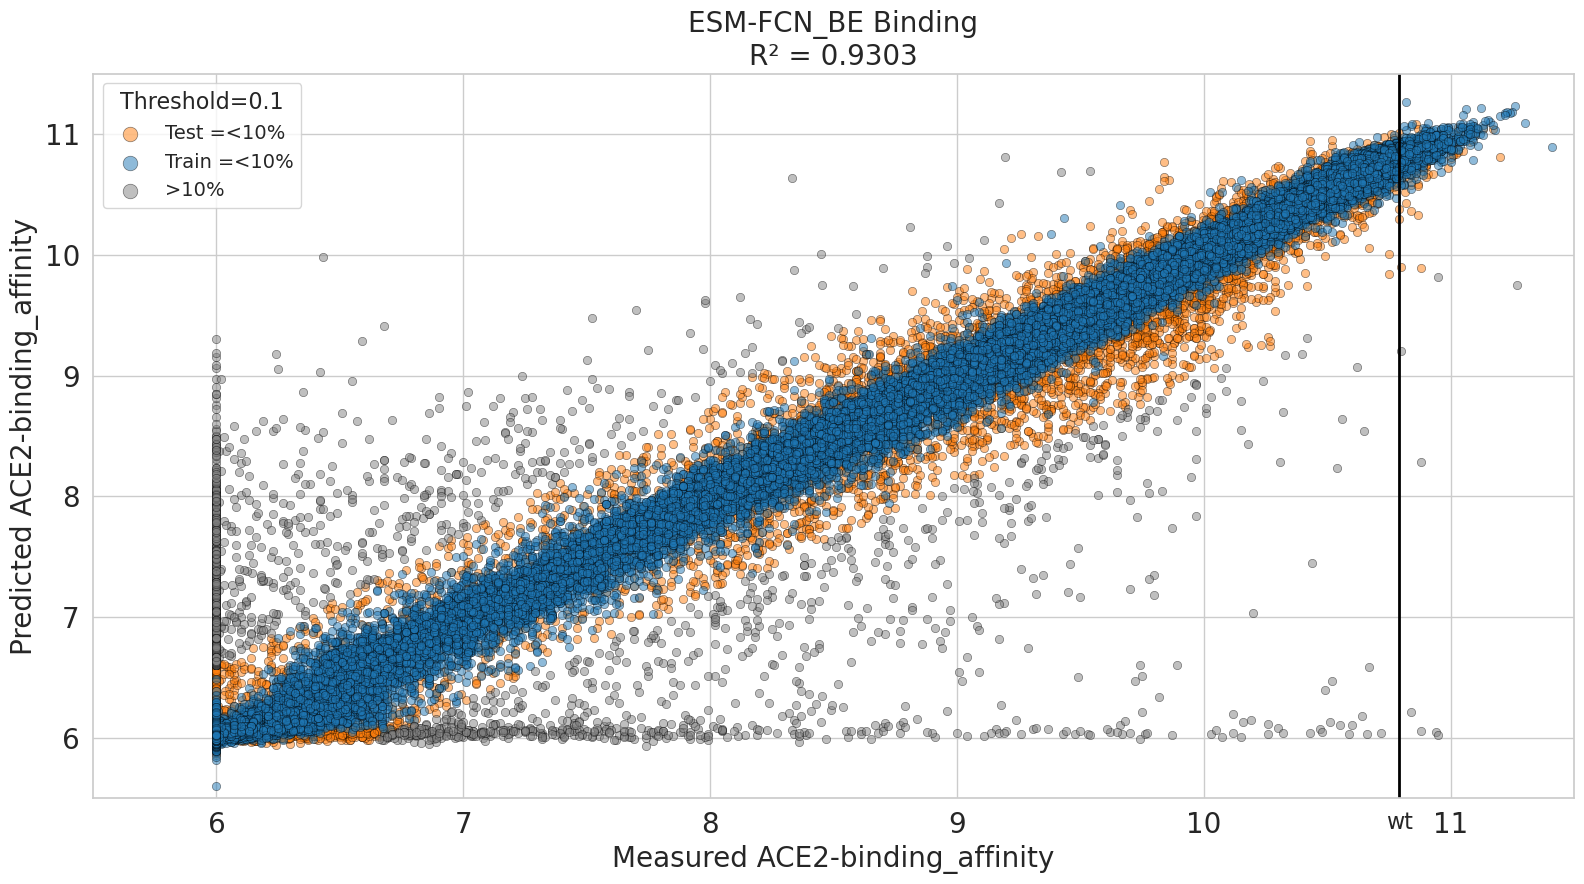

In [12]:
# A
plot_predicted_value_scatter_with_threshold(merged_df, "ACE2-binding_affinity", "binding_predicted_value", "ESM-FCN_BE Binding", "../../results/plots/measured_vs_predicted/esm_fcn_BE.binding-scatter.pdf", binding_wt)

R^2 outside of threshold: -0.08913321661728757
R^2 inside of threshold: 0.9218743917099939


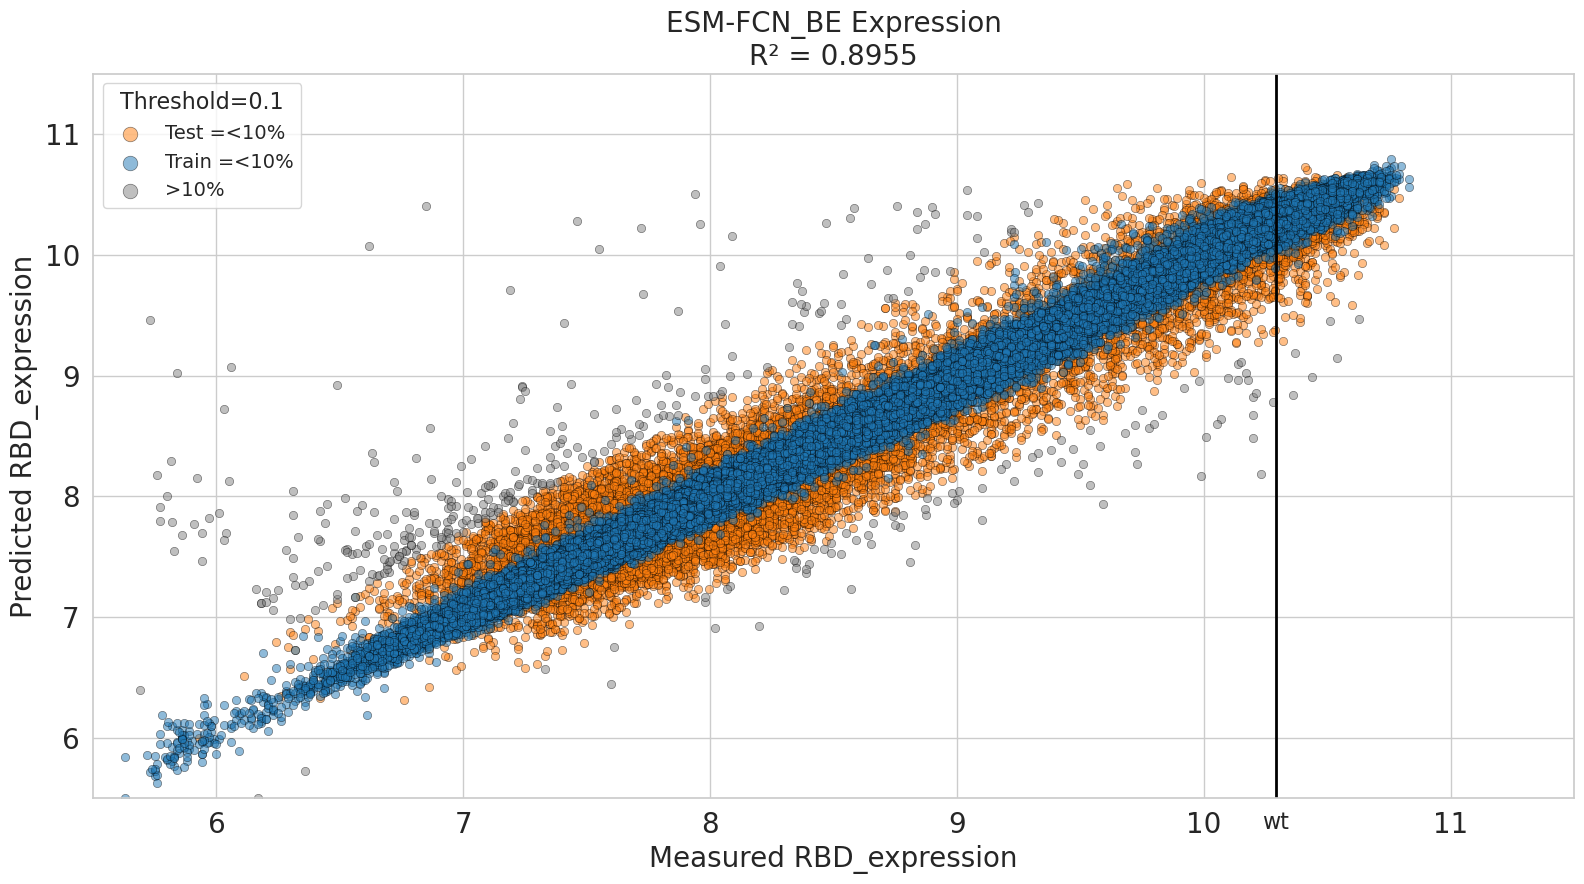

In [13]:
# B
plot_predicted_value_scatter_with_threshold(merged_df, "RBD_expression", "expression_predicted_value", "ESM-FCN_BE Expression", "../../results/plots/measured_vs_predicted/esm_fcn_BE.expression-scatter.pdf", expression_wt)

Histogram figure of frequent mutations for ESM-GCN_BE.

In [14]:
# Binding
binding_df = merged_df[["seq_id", "binding_predicted_value", "ACE2-binding_affinity", "mode"]].copy()
binding_df["percentage_error"] = ((merged_df["binding_predicted_value"] - merged_df["ACE2-binding_affinity"]) / merged_df["ACE2-binding_affinity"]) * 100
binding_df

,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error
0,SARS-CoV-2-S19E_E141G_N157A,6.025325,6.000000,train,0.422088
1,SARS-CoV-2-T63F_Y178V_S184L,9.118689,9.160000,train,-0.450998
2,SARS-CoV-2-W106A_G146C,6.065585,6.000000,train,1.093086
3,SARS-CoV-2-A18C_R25V_L122T_P149R,6.147402,6.130000,train,0.283887
4,SARS-CoV-2-D59W_P96S,10.168621,10.160000,train,0.084853
...,...,...,...,...,...
102718,SARS-CoV-2-V11A_V32G_W106G_G146H,6.054747,6.000000,test,0.912444
102719,SARS-CoV-2-T3G_K48P_G83E_S147V_V173S,6.322847,6.000000,test,5.380781
102720,SARS-CoV-2-K94H,10.710976,10.718333,test,-0.068646
102721,SARS-CoV-2-T46L_S139T_F185Q,9.576644,9.320000,test,2.753690


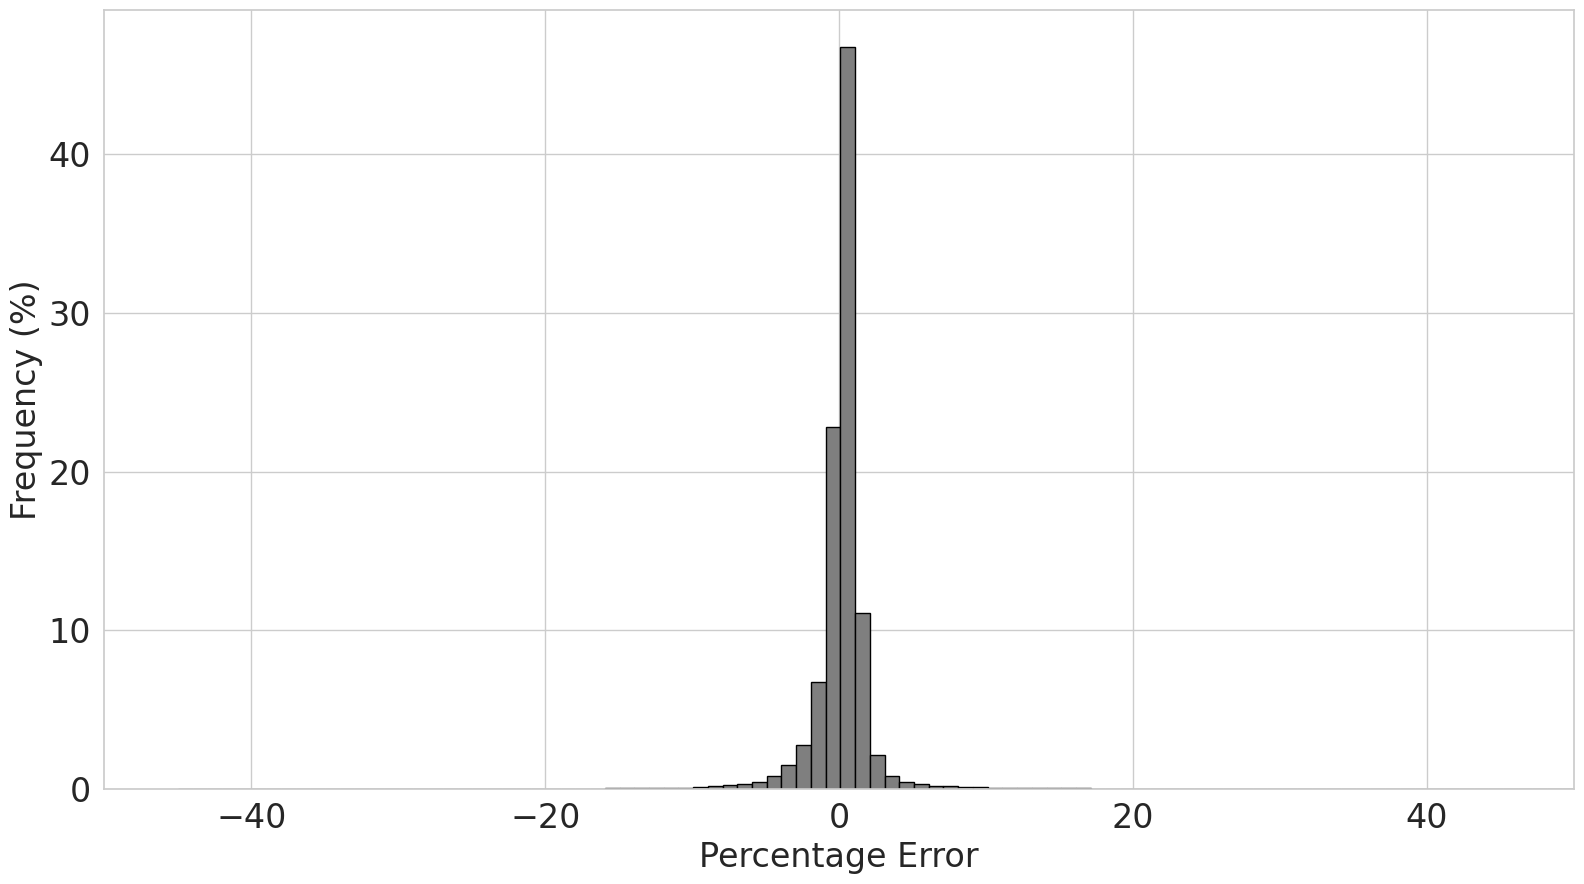

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 9))
plt.hist(
    binding_df["percentage_error"], 
    bins=100, 
    weights=[100 / len(binding_df)] * len(binding_df), 
    edgecolor='black', 
    color='tab:grey'
)

fontsize = 24
plt.xlim(-50, 50)  
plt.xlabel("Percentage Error", fontsize=fontsize)
plt.ylabel("Frequency (%)", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/esm_fcn_BE.binding-percent_error_histogram.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

Now let's pull the outliers from top and bottom 2.5%.

In [16]:
lower_bound = binding_df['percentage_error'].quantile(0.025)
upper_bound = binding_df['percentage_error'].quantile(0.975)

outliers = binding_df[(binding_df['percentage_error'] < lower_bound) | (binding_df['percentage_error'] > upper_bound)].reset_index(drop=True)
outliers

,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error
0,SARS-CoV-2-D90T_R179H,7.640113,7.30,train,4.659081
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929
2,SARS-CoV-2-R127Q_Q144E,8.697819,8.24,train,5.556053
3,SARS-CoV-2-F12Y_F99A_A105S_A145V,6.144325,6.80,train,-9.642276
4,SARS-CoV-2-P54T_E141R,10.176861,9.38,train,8.495318
...,...,...,...,...,...
5133,SARS-CoV-2-I28A_S41N_C49W_C61N_K94A_F160G_N171Y,6.823151,6.00,test,13.719177
5134,SARS-CoV-2-N40L_L57C_T201S,9.697086,9.28,test,4.494465
5135,SARS-CoV-2-G86Y_K132R_Y175F,6.712379,7.95,test,-15.567560
5136,SARS-CoV-2-T3G_K48P_G83E_S147V_V173S,6.322847,6.00,test,5.380781


We need to adjust the seq_id to acquire the mutations from the data. 

The Spike receptor binding domain (RBD) from SARS-CoV-2 (isolate Wuhan-Hu-1, GenBank : MN908947, residues N331-T531) (checked [Deep Mutational Scanning of SARS-CoV-2 Receptor Binding Domain Reveals Constraints on Folding and ACE2 Binding](https://www.cell.com/cell/fulltext/S0092-8674(20)31003-5?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0092867420310035%3Fshowall%3Dtrue)). So we need to add 330 to get the RBD site (data not 0 indexed).

In [17]:
df = outliers.copy()
df['target'] = df['seq_id'].str.rsplit('-', n=1).str[0]
df['aa_substitutions'] = df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
print(len(df))

df = df.explode('aa_substitutions')
print(len(df))

df['RBD_mutation_site'] = df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 330 # Extract numeric site, RBD site
df['original_aa'] = df['aa_substitutions'].str[0]
df['new_aa'] = df['aa_substitutions'].str[-1]
df['aa_sub'] = df['original_aa'] + ">" + df['new_aa']
df.head(10)

5138
16906


,seq_id,binding_predicted_value,ACE2-binding_affinity,mode,percentage_error,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-D90T_R179H,7.640113,7.30,train,4.659081,SARS-CoV-2,D90T,420,D,T,D>T
0,SARS-CoV-2-D90T_R179H,7.640113,7.30,train,4.659081,SARS-CoV-2,R179H,509,R,H,R>H
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929,SARS-CoV-2,L95P,425,L,P,L>P
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929,SARS-CoV-2,G116L,446,G,L,G>L
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929,SARS-CoV-2,Y123E,453,Y,E,Y>E
1,SARS-CoV-2-L95P_G116L_Y123E_Y143V,6.733933,6.42,train,4.889929,SARS-CoV-2,Y143V,473,Y,V,Y>V
2,SARS-CoV-2-R127Q_Q144E,8.697819,8.24,train,5.556053,SARS-CoV-2,R127Q,457,R,Q,R>Q
2,SARS-CoV-2-R127Q_Q144E,8.697819,8.24,train,5.556053,SARS-CoV-2,Q144E,474,Q,E,Q>E
3,SARS-CoV-2-F12Y_F99A_A105S_A145V,6.144325,6.80,train,-9.642276,SARS-CoV-2,F12Y,342,F,Y,F>Y
3,SARS-CoV-2-F12Y_F99A_A105S_A145V,6.144325,6.80,train,-9.642276,SARS-CoV-2,F99A,429,F,A,F>A


Here we will look at the total mutations possible that occur at a particular site across all seq_ids in our outliers. Then we will break it down by amino acid.

In [18]:
from collections import Counter

original_aa_dict = df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
new_aa_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()

new_aa_total_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(f"Per site total mutations: {new_aa_total_ct_dict}")

new_aa_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(f"Per site, per new amino acid substitution total: {sorted_new_aa_ct_dict}")

Per site total mutations: {331: 101, 332: 118, 333: 123, 334: 86, 335: 158, 336: 148, 337: 84, 338: 92, 339: 156, 340: 92, 341: 70, 342: 113, 343: 90, 344: 140, 345: 98, 346: 51, 347: 60, 348: 56, 349: 80, 350: 67, 351: 42, 352: 53, 353: 76, 354: 41, 355: 58, 356: 43, 357: 59, 358: 73, 359: 38, 360: 36, 361: 49, 362: 44, 363: 105, 364: 103, 365: 123, 366: 85, 367: 120, 368: 75, 369: 71, 370: 62, 371: 127, 372: 102, 373: 79, 374: 141, 375: 121, 376: 59, 377: 58, 378: 67, 379: 120, 380: 90, 381: 92, 382: 50, 383: 51, 384: 65, 385: 117, 386: 127, 387: 83, 388: 70, 389: 102, 390: 134, 391: 221, 392: 77, 393: 106, 394: 104, 395: 34, 396: 48, 397: 39, 398: 99, 399: 57, 400: 37, 401: 50, 402: 46, 403: 45, 404: 42, 405: 23, 406: 54, 407: 84, 408: 40, 409: 8, 410: 30, 411: 93, 412: 99, 413: 145, 414: 96, 415: 88, 416: 145, 417: 149, 418: 72, 419: 162, 420: 227, 421: 153, 422: 52, 423: 66, 424: 148, 425: 123, 426: 146, 427: 139, 428: 156, 429: 167, 430: 142, 431: 44, 432: 42, 433: 167, 434: 125,

Let's make this into a proper table. 

In [19]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Possible Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

possible_mutations_per_site = pd.DataFrame(data)
print(possible_mutations_per_site.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                              Amino Acid Substitutions (Count)
      331                   N                       101                 L(16), S(11), K(10), M(7), E(7), Y(7), R(6), V(5), T(5), G(4), W(4), I(4), P(4), F(4), Q(3), D(2), H(1), C(1)
      332                   I                       118          T(14), L(13), V(12), S(12), N(7), K(7), F(6), R(6), G(6), M(5), A(5), H(4), Y(4), W(4), P(4), D(3), E(2), C(2), Q(2)
      333                   T                       123          S(16), L(13), R(11), N(10), P(8), F(7), C(6), V(6), E(6), I(5), D(5), M(5), G(5), W(5), K(5), H(3), A(3), Q(2), Y(2)
      334                   N                        86             S(11), T(9), R(7), L(7), P(7), Y(6), K(5), A(5), F(5), M(4), H(4), C(3), V(2), D(2), E(2), G(2), I(2), Q(2), W(1)
      335                   L                       158        T(17), R(17), S(15), Y(11),

Let's take a look at the top 10 sites with the highest total possible mutations occuring at that spot.

In [20]:
# Sort and display the top 10
possible_mutations_per_site['Total Possible Mutations'] = pd.to_numeric(possible_mutations_per_site['Total Possible Mutations'])
top_10_highest = possible_mutations_per_site.sort_values('Total Possible Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                              Amino Acid Substitutions (Count)
      531                   T                       230     R(29), S(27), K(23), L(21), V(19), M(14), Q(10), E(10), C(10), N(9), W(9), A(8), P(8), F(7), G(6), H(6), I(6), Y(5), D(3)
      420                   D                       227   R(25), S(23), N(19), Y(18), L(18), T(16), I(16), G(13), V(12), K(11), H(10), M(9), F(9), A(8), C(6), E(5), Q(4), W(4), P(1)
      391                   C                       221 S(20), K(17), V(16), R(15), M(15), I(13), P(12), A(12), T(12), L(11), F(11), Y(10), N(10), W(9), E(9), G(9), D(7), H(7), Q(6)
      436                   W                       213           L(28), R(27), S(24), V(17), T(16), I(12), K(11), C(11), M(10), N(9), A(8), Y(7), G(7), E(7), Q(6), P(5), D(4), F(4)
      437                   N                       200       L(22), T(22), P(20), S(19), 

Now, for each site we will grab the top 10 (as available) "binding_predicted_value" scores for each site. And then we will find the highest score predicted score per site. We save the measured value "ACE2-binding_affinity", and we can use this as a coordinate value associated with it's percentage error.

In [41]:
# Group by 'RBD_mutation_site' and extract top 10 binding_predicted_value scores for each site
top_p_scores_dict = df.groupby('RBD_mutation_site').apply(
    lambda x: x.nlargest(10, 'binding_predicted_value')[['new_aa', 'ACE2-binding_affinity', 'binding_predicted_value', 'percentage_error']].values.tolist()
).to_dict()

# Find the highest binding_predicted_value score for each site
highest_p_scores = {site: max(scores, key=lambda x: x[2])[2] if scores else 0 for site, scores in top_p_scores_dict.items()}

data = []
for site, max_score in highest_p_scores.items():
    total = new_aa_total_ct_dict[site]
    scores = top_p_scores_dict.get(site, [])
    scores_str = ', '.join([f'{aa}(({m_score:.2f}, {p_score:.2f}), {perc_error:.2f}%)' for aa, m_score, p_score, perc_error in scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest Predicted Binding Value': f'{max_score:.2f}',
        'Measured and Predicted Binding Values ((m, p), %_err)': scores_str
    })

top_10_scores_per_site = pd.DataFrame(data)
print(top_10_scores_per_site.to_string(index=False))


 RBD Site  Total Mutations Original Amino Acid Highest Predicted Binding Value                                                                                                                                                                                                         Measured and Predicted Binding Values ((m, p), %_err)
      331              101                   N                           10.61       L((10.08, 10.61), 5.24%), F((9.69, 10.08), 4.04%), L((9.37, 9.91), 5.80%), S((9.39, 9.76), 3.97%), Y((7.98, 9.60), 20.28%), W((7.70, 9.54), 23.90%), R((8.87, 9.41), 6.05%), Q((10.27, 9.29), -9.55%), L((9.87, 9.19), -6.90%), T((9.62, 9.12), -5.24%)
      332              118                   I                           10.67        S((10.26, 10.67), 3.96%), F((8.88, 9.99), 12.48%), G((10.27, 9.65), -6.00%), W((9.11, 9.53), 4.66%), T((9.07, 9.53), 5.07%), R((8.86, 9.27), 4.65%), S((8.68, 9.05), 4.21%), V((9.48, 9.03), -4.74%), N((9.48, 8.98), -5.24%), H((9.54, 8.95), -6.17%)
 

Top 10.

In [42]:
# Sort and display the top 10
top_10_scores_per_site['Highest Predicted Binding Value'] = pd.to_numeric(top_10_scores_per_site['Highest Predicted Binding Value'])
top_10_highest = top_10_scores_per_site.sort_values('Highest Predicted Binding Value', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid  Highest Predicted Binding Value                                                                                                                                                                                                        Measured and Predicted Binding Values ((m, p), %_err)
      413              145                   G                            11.27      R((10.82, 11.27), 4.15%), F((11.41, 10.89), -4.53%), I((8.96, 10.08), 12.47%), I((9.39, 9.90), 5.46%), K((9.31, 9.86), 5.88%), F((9.28, 9.83), 5.89%), V((9.43, 9.82), 4.18%), H((9.28, 9.75), 5.03%), R((10.29, 9.69), -5.81%), S((9.07, 9.53), 5.07%)
      455               51                   L                            11.27     Q((10.82, 11.27), 4.15%), A((8.81, 10.23), 16.13%), G((10.95, 9.81), -10.39%), M((10.19, 9.64), -5.43%), Q((9.05, 9.55), 5.50%), A((9.16, 9.54), 4.17%), C((9.01, 9.46), 5.04%), A((9.89, 9.39), -5.05%), V((8.86, 9.27), 4.65%), S((8.68, 9.03), 4.08%)
 

Now for expression:

In [43]:
# Expression
expression_df = merged_df[["seq_id", "expression_predicted_value", "RBD_expression", "mode"]].copy()
expression_df["percentage_error"] = ((merged_df["expression_predicted_value"] - merged_df["RBD_expression"]) / merged_df["RBD_expression"]) * 100
expression_df

,seq_id,expression_predicted_value,RBD_expression,mode,percentage_error
0,SARS-CoV-2-S19E_E141G_N157A,8.142976,8.1700,train,-0.330773
1,SARS-CoV-2-T63F_Y178V_S184L,7.969032,8.1100,train,-1.738202
2,SARS-CoV-2-W106A_G146C,7.642408,7.5900,train,0.690486
3,SARS-CoV-2-A18C_R25V_L122T_P149R,8.450376,8.4200,train,0.360755
4,SARS-CoV-2-D59W_P96S,8.058466,8.0200,train,0.479625
...,...,...,...,...,...
102718,SARS-CoV-2-V11A_V32G_W106G_G146H,7.899178,7.7700,test,1.662517
102719,SARS-CoV-2-T3G_K48P_G83E_S147V_V173S,7.636149,7.8300,test,-2.475748
102720,SARS-CoV-2-K94H,9.883184,10.0475,test,-1.635388
102721,SARS-CoV-2-T46L_S139T_F185Q,7.648870,7.5900,test,0.775619


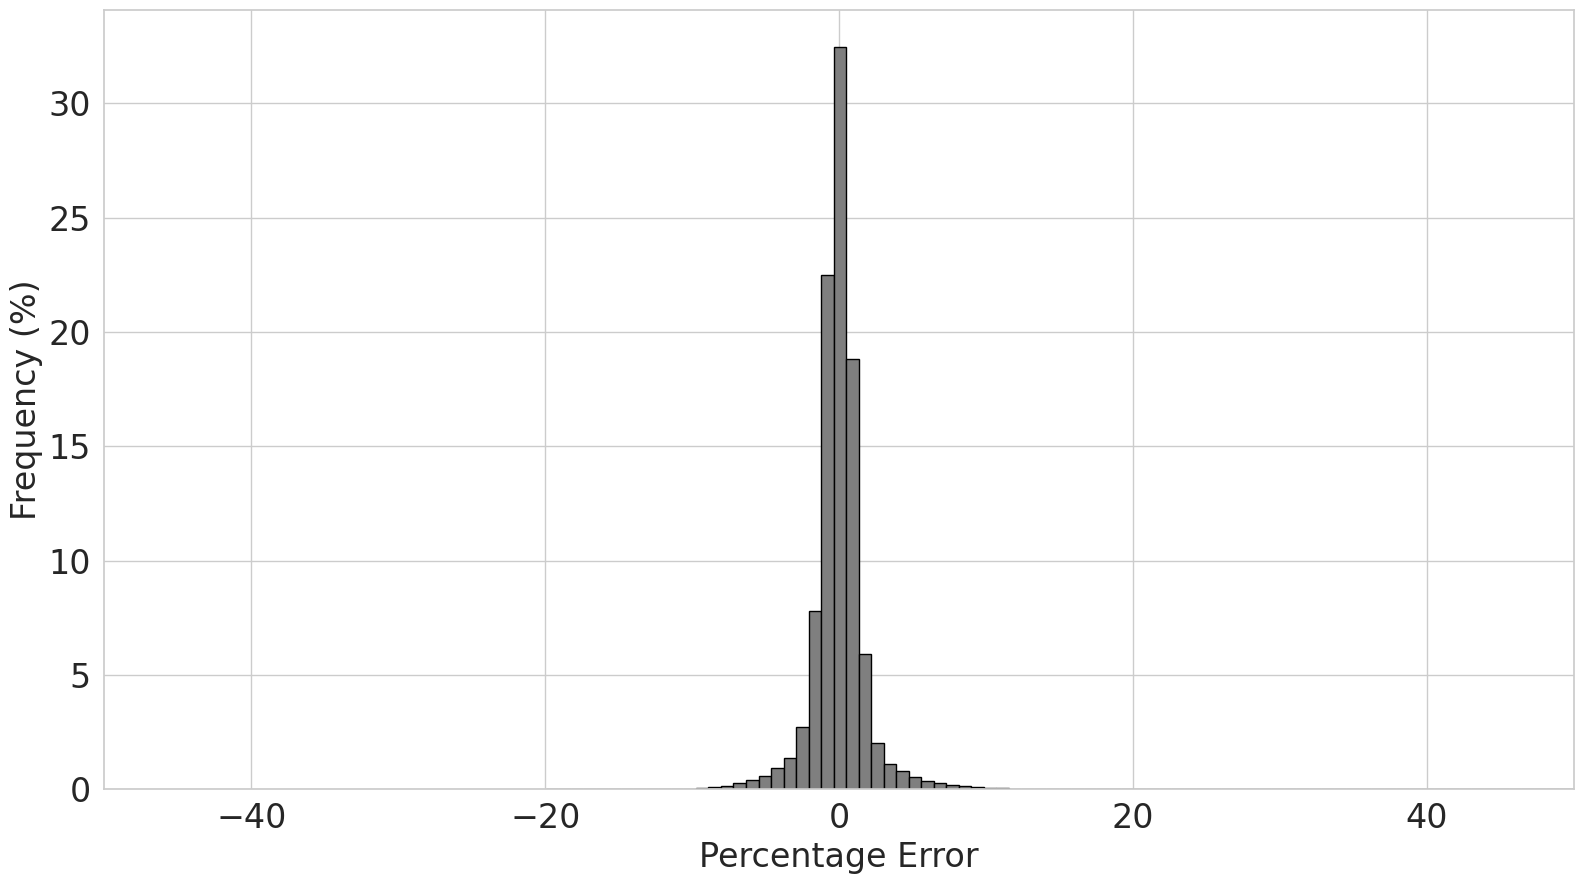

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 9))
plt.hist(
    expression_df["percentage_error"], 
    bins=100, 
    weights=[100 / len(expression_df)] * len(expression_df), 
    edgecolor='black', 
    color='tab:grey'
)

fontsize = 24
plt.xlim(-50, 50)  
plt.xlabel("Percentage Error", fontsize=fontsize)
plt.ylabel("Frequency (%)", fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()

save_as = "../../results/plots/measured_vs_predicted/esm_fcn_BE.expression-percent_error_histogram.pdf"
plt.savefig(save_as, format='pdf')
plt.savefig(save_as.replace('.pdf', '.png'), format='png')

In [45]:
lower_bound = expression_df['percentage_error'].quantile(0.025)
upper_bound = expression_df['percentage_error'].quantile(0.975)

outliers = expression_df[(expression_df['percentage_error'] < lower_bound) | (expression_df['percentage_error'] > upper_bound)].reset_index(drop=True)
outliers

,seq_id,expression_predicted_value,RBD_expression,mode,percentage_error
0,SARS-CoV-2-A89C_F134G,9.569935,9.10,train,5.164119
1,SARS-CoV-2-V37F_F99S,8.628573,7.91,train,9.084367
2,SARS-CoV-2-C6Q_T201P,6.100972,5.82,train,4.827692
3,SARS-CoV-2-G9A_A42Y_L95A_T201N,7.542988,7.12,train,5.940847
4,SARS-CoV-2-R27I,9.254446,8.67,train,6.741015
...,...,...,...,...,...
5133,SARS-CoV-2-A89F_R124T_P133W_C150M,7.742808,8.15,test,-4.996223
5134,SARS-CoV-2-D34S_T100M_N110Y_Q144R_P191F,7.302727,6.90,test,5.836620
5135,SARS-CoV-2-N30D_F99P_W106S_F134S_N157K_C158K,7.601234,8.25,test,-7.863831
5136,SARS-CoV-2-G152I_F167D,7.916143,8.29,test,-4.509735


In [46]:
df = outliers.copy()
df['target'] = df['seq_id'].str.rsplit('-', n=1).str[0]
df['aa_substitutions'] = df['seq_id'].str.rsplit('-', n=1).str[1].str.rsplit('_')
print(len(df))

df = df.explode('aa_substitutions')
print(len(df))

df['RBD_mutation_site'] = df['aa_substitutions'].str.extract(r'(\d+)').astype(int) + 330 # Extract numeric site, RBD site
df['original_aa'] = df['aa_substitutions'].str[0]
df['new_aa'] = df['aa_substitutions'].str[-1]
df['aa_sub'] = df['original_aa'] + ">" + df['new_aa']
df.head(10)

5138
17245


,seq_id,expression_predicted_value,RBD_expression,mode,percentage_error,target,aa_substitutions,RBD_mutation_site,original_aa,new_aa,aa_sub
0,SARS-CoV-2-A89C_F134G,9.569935,9.10,train,5.164119,SARS-CoV-2,A89C,419,A,C,A>C
0,SARS-CoV-2-A89C_F134G,9.569935,9.10,train,5.164119,SARS-CoV-2,F134G,464,F,G,F>G
1,SARS-CoV-2-V37F_F99S,8.628573,7.91,train,9.084367,SARS-CoV-2,V37F,367,V,F,V>F
1,SARS-CoV-2-V37F_F99S,8.628573,7.91,train,9.084367,SARS-CoV-2,F99S,429,F,S,F>S
2,SARS-CoV-2-C6Q_T201P,6.100972,5.82,train,4.827692,SARS-CoV-2,C6Q,336,C,Q,C>Q
2,SARS-CoV-2-C6Q_T201P,6.100972,5.82,train,4.827692,SARS-CoV-2,T201P,531,T,P,T>P
3,SARS-CoV-2-G9A_A42Y_L95A_T201N,7.542988,7.12,train,5.940847,SARS-CoV-2,G9A,339,G,A,G>A
3,SARS-CoV-2-G9A_A42Y_L95A_T201N,7.542988,7.12,train,5.940847,SARS-CoV-2,A42Y,372,A,Y,A>Y
3,SARS-CoV-2-G9A_A42Y_L95A_T201N,7.542988,7.12,train,5.940847,SARS-CoV-2,L95A,425,L,A,L>A
3,SARS-CoV-2-G9A_A42Y_L95A_T201N,7.542988,7.12,train,5.940847,SARS-CoV-2,T201N,531,T,N,T>N


In [47]:
from collections import Counter

original_aa_dict = df.groupby('RBD_mutation_site')['original_aa'].apply(lambda x: list(set(x))).to_dict()
new_aa_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(set(x))).to_dict()

new_aa_total_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].count().to_dict()
print(f"Per site total mutations: {new_aa_total_ct_dict}")

new_aa_ct_dict = df.groupby('RBD_mutation_site')['new_aa'].apply(lambda x: list(Counter(x).items())).to_dict()
sorted_new_aa_ct_dict = {k: sorted(v, key=lambda x: x[1], reverse=True) for k, v in new_aa_ct_dict.items()}
print(f"Per site, per new amino acid substitution total: {sorted_new_aa_ct_dict}")

Per site total mutations: {331: 83, 332: 146, 333: 109, 334: 113, 335: 196, 336: 168, 337: 81, 338: 81, 339: 149, 340: 97, 341: 71, 342: 98, 343: 93, 344: 148, 345: 135, 346: 71, 347: 48, 348: 50, 349: 81, 350: 49, 351: 38, 352: 50, 353: 61, 354: 40, 355: 60, 356: 52, 357: 79, 358: 57, 359: 40, 360: 36, 361: 44, 362: 42, 363: 116, 364: 121, 365: 129, 366: 91, 367: 136, 368: 95, 369: 82, 370: 72, 371: 190, 372: 140, 373: 83, 374: 152, 375: 119, 376: 55, 377: 57, 378: 73, 379: 93, 380: 76, 381: 104, 382: 56, 383: 53, 384: 69, 385: 148, 386: 132, 387: 73, 388: 76, 389: 90, 390: 143, 391: 221, 392: 83, 393: 114, 394: 125, 395: 41, 396: 45, 397: 29, 398: 96, 399: 53, 400: 42, 401: 46, 402: 34, 403: 36, 404: 39, 405: 20, 406: 34, 407: 89, 408: 38, 409: 13, 410: 37, 411: 85, 412: 84, 413: 130, 414: 94, 415: 97, 416: 171, 417: 155, 418: 93, 419: 119, 420: 239, 421: 136, 422: 81, 423: 66, 424: 109, 425: 113, 426: 129, 427: 159, 428: 134, 429: 158, 430: 140, 431: 65, 432: 57, 433: 113, 434: 99, 

In [48]:
data = []
for site in sorted(new_aa_total_ct_dict.keys()):
    total = new_aa_total_ct_dict[site]
    mutations = sorted_new_aa_ct_dict[site]
    mutation_str = ', '.join([f"{aa}({count})" for aa, count in mutations])
    data.append({
        'RBD Site': site,
        'Original Amino Acid': original_aa_dict[site][0],
        'Total Possible Mutations': total,
        'Amino Acid Substitutions (Count)': mutation_str
    })

possible_mutations_per_site = pd.DataFrame(data)
print(possible_mutations_per_site.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                                Amino Acid Substitutions (Count)
      331                   N                        83                L(9), S(9), R(8), K(8), D(6), T(6), G(5), I(4), H(4), P(3), W(3), Q(3), M(3), Y(2), A(2), C(2), V(2), E(2), F(2)
      332                   I                       146          S(20), R(15), V(15), L(14), G(13), T(10), N(9), P(7), A(7), F(7), Y(7), H(4), K(4), E(3), W(3), C(3), D(2), Q(2), M(1)
      333                   T                       109               S(15), R(9), F(9), N(7), K(7), I(7), V(6), A(6), C(6), L(5), E(5), P(5), G(5), H(4), Y(4), Q(3), D(2), W(2), M(2)
      334                   N                       113              L(11), K(10), S(9), P(8), M(8), T(8), V(7), A(7), F(7), R(7), I(6), Y(6), D(4), G(4), W(4), H(3), E(2), C(1), Q(1)
      335                   L                       196      R(22), S(18), V(15)

In [49]:
# Sort and display the top 10
possible_mutations_per_site['Total Possible Mutations'] = pd.to_numeric(possible_mutations_per_site['Total Possible Mutations'])
top_10_highest = possible_mutations_per_site.sort_values('Total Possible Mutations', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site Original Amino Acid  Total Possible Mutations                                                                                                Amino Acid Substitutions (Count)
      531                   T                       270  R(32), L(23), V(21), S(20), K(19), N(18), Y(17), P(16), M(16), I(16), G(12), A(10), Q(10), W(10), D(8), C(7), E(7), H(5), F(3)
      420                   D                       239 S(26), Y(23), H(21), L(20), R(16), K(15), E(13), C(12), V(11), I(11), N(11), M(11), G(11), A(10), T(10), P(7), F(6), W(4), Q(1)
      391                   C                       221      L(27), S(17), V(16), R(16), Y(15), G(15), K(13), T(13), A(12), I(11), N(9), P(9), E(8), D(8), F(7), H(7), M(6), W(6), Q(6)
      335                   L                       196      R(22), S(18), V(15), P(14), G(12), I(11), N(10), T(10), H(10), M(10), F(9), K(9), W(8), C(7), E(7), D(7), A(6), Q(6), Y(5)
      371                   S                       190        L(21), T(18), Y(1

In [50]:
# Group by 'RBD_mutation_site' and extract top 10 expression_predicted_value scores for each site
top_p_scores_dict = df.groupby('RBD_mutation_site').apply(
    lambda x: x.nlargest(10, 'expression_predicted_value')[['new_aa', 'RBD_expression', 'expression_predicted_value', 'percentage_error']].values.tolist()
).to_dict()

# Find the highest expression_predicted_value score for each site
highest_p_scores = {site: max(scores, key=lambda x: x[2])[2] if scores else 0 for site, scores in top_p_scores_dict.items()}

data = []
for site, max_score in highest_p_scores.items():
    total = new_aa_total_ct_dict[site]
    scores = top_p_scores_dict.get(site, [])
    scores_str = ', '.join([f'{aa}(({m_score:.2f}, {p_score:.2f}), {perc_error:.2f}%)' for aa, m_score, p_score, perc_error in scores])
    data.append({
        'RBD Site': site,
        'Total Mutations': total,
        'Original Amino Acid': original_aa_dict[site][0],
        'Highest Predicted Expression Value': f'{max_score:.2f}',
        'Measured and Predicted Expression Values ((m, p), %_err)': scores_str
    })

top_10_scores_per_site = pd.DataFrame(data)
print(top_10_scores_per_site.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid Highest Predicted Expression Value                                                                                                                                                                                                             Measured and Predicted Expression Values ((m, p), %_err)
      331               83                   N                              10.32          Q((9.69, 10.32), 6.55%), K((9.60, 10.32), 7.52%), D((8.57, 10.30), 20.23%), P((10.62, 10.20), -3.98%), P((9.71, 10.18), 4.76%), R((9.41, 10.09), 7.19%), L((9.24, 9.86), 6.75%), P((10.36, 9.85), -4.95%), M((10.27, 9.81), -4.51%), R((9.21, 9.69), 5.25%)
      332              146                   I                              10.54          S((10.07, 10.54), 4.66%), S((9.98, 10.50), 5.20%), Y((10.03, 10.47), 4.34%), W((9.74, 10.38), 6.60%), L((9.78, 10.31), 5.40%), G((10.59, 10.17), -3.94%), H((9.55, 9.99), 4.58%), N((9.34, 9.93), 6.29%), L((10.27, 9.87), -3.8

In [51]:
# Sort and display the top 10
top_10_scores_per_site['Highest Predicted Expression Value'] = pd.to_numeric(top_10_scores_per_site['Highest Predicted Expression Value'])
top_10_highest = top_10_scores_per_site.sort_values('Highest Predicted Expression Value', ascending=False).head(10)
print(top_10_highest.to_string(index=False))

 RBD Site  Total Mutations Original Amino Acid  Highest Predicted Expression Value                                                                                                                                                                                                       Measured and Predicted Expression Values ((m, p), %_err)
      365              129                   Y                               10.64   M((10.11, 10.64), 5.25%), L((9.94, 10.35), 4.13%), V((7.55, 10.04), 33.04%), F((10.32, 9.87), -4.39%), I((10.21, 9.80), -4.03%), F((10.42, 9.66), -7.31%), T((9.12, 9.57), 4.93%), V((9.89, 9.45), -4.42%), L((8.74, 9.43), 7.94%), I((10.02, 9.43), -5.90%)
      354               40                   N                               10.64    K((10.11, 10.64), 5.25%), R((9.87, 10.41), 5.47%), G((9.58, 9.97), 4.12%), V((9.13, 9.92), 8.63%), R((10.30, 9.85), -4.35%), L((10.28, 9.73), -5.36%), A((9.25, 9.67), 4.57%), T((10.04, 9.62), -4.17%), R((10.53, 9.61), -8.76%), D((10.00, 9